# Modelagem — escola–ano (Ensino Médio)

Este notebook documenta a **etapa de Machine Learning** com quatro algoritmos em papéis distintos:

| Algoritmo | Papel |
|-----------|--------|
| **HistGradientBoostingRegressor** | Regressão principal — previsão de `taxa_abandono_em`, ranking de risco e modelo final ajustado |
| **DecisionTreeRegressor** | Regras interpretáveis e thresholds para gestão escolar |
| **KNeighborsRegressor** | Escolas semelhantes / benchmarking |
| **KMeans** | Segmentação de perfis (não supervisionada nas covariáveis) |

- **Requisito 3:** ETL, EDA, pipelines (`ml/baseline_municipio.py`).
- **Requisitos 4 e 5:** validação temporal (treino `<= 2017`, teste `>= 2018`), métricas **MAE**, **RMSE**, **R²** e comparação entre regressores.
- **Requisitos 6 e 7:** ajuste de hiperparâmetros com **RandomizedSearchCV**, **TimeSeriesSplit por ano**, validação cruzada temporal e curva de aprendizado.
- **Requisitos 8 e 9:** função explícita de inferência (`edu.predict_taxa_abandono_em`) e exportação do **bundle final** em `outputs/ml/final_model_bundle.pkl`.
- **Requisito 10:** integração ao dashboard e narrativa metodológica em `ml/educational_ml.py`, `outputs/ml/` e `dashboard/app.py`.

**Granularidade:** `fato_integrado` — **uma linha por escola e ano**.  
**Alvo:** `taxa_abandono_em`. **Exclusão:** não usar `indice_risco_evasao` como preditor.


## 1. Ambiente e reprodutibilidade

Execute a partir da **raiz do repositório** (para que `data/` e `ml/` resolvam corretamente). Versões recomendadas: `requirements.txt`.

### Este notebook ainda é necessário?

**Sim.** Ele continua a ser o local onde se:
- exploram os dados (EDA);
- documentam o split temporal e as métricas;
- **geram** os ficheiros em `outputs/ml/` e `outputs/figures/` que o **dashboard** lê.

A lógica dos algoritmos está nos módulos Python (`ml/baseline_municipio.py`, `ml/educational_ml.py`); o notebook é o **roteiro reprodutível** para correr essa lógica e validar resultados.

### Onde ver as alterações (algoritmos e resultados)

| O quê | Onde |
|------|------|
| Código dos regressores (HGB, árvore, KNN) e pré-processamento | `ml/baseline_municipio.py` |
| Suite completa (comparação, KMeans, vizinhos, exportação, narrativas) | `ml/educational_ml.py` |
| Tabelas CSV + JSON para storytelling | `outputs/ml/` (`escola_ano_ml_enriquecido.csv`, `ml_storytelling.json`, …) |
| Figuras (árvore, KMeans, HGB, comparação) | `outputs/figures/` (`ml_*.png`, `model_comparison_*.png`) |
| Painel para não técnicos (após gerar os artefactos acima) | Streamlit → secção **«5. Conclusoes e Modelo Preditivo»** → bloco *Apoio inteligente* (`dashboard/app.py`) |


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "ml").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from ml import baseline_municipio as bl
from ml import educational_ml as edu

## 2. Carregamento dos dados

Se `data/processed/fato_integrado.csv` não existir, o módulo **dispara o ETL automaticamente** (mesma lógica do dashboard).

In [2]:
df = bl.load_fato_integrado()
df = df.sort_values("ano").reset_index(drop=True)
print("Dimensão:", df.shape)
print("Anos:", df["ano"].min(), "—", df["ano"].max())
df.head()

Dimensão: (98, 26)
Anos: 2008 — 2022


,ano,id_municipio,id_municipio_nome,atu_ef,atu_em,had_ef,had_em,tdi_ef,tdi_em,taxa_aprovacao_ef,...,id_linha_educacional,risco_ef,risco_em,taxa_promocao_ef,taxa_promocao_em,taxa_repetencia_ef,taxa_repetencia_em,taxa_evasao_ef,taxa_evasao_em,indice_risco_evasao
0,2008,2611606,Recife,26.6,NaN,NaN,NaN,24.6,NaN,86.7,...,17,Baixo,Sem dado,70.97,64.6,9.28,7.9,12.65,27.07,18.85
1,2008,2611606,Recife,32.5,34.2,NaN,NaN,6.9,72.8,95.0,...,18,Baixo,Baixo,70.97,64.6,9.28,7.9,12.65,27.07,35.04
2,2008,2611606,Recife,20.1,37.7,NaN,NaN,6.4,9.3,95.3,...,19,Baixo,Baixo,70.97,64.6,9.28,7.9,12.65,27.07,15.99
3,2008,2611606,Recife,26.8,38.2,NaN,NaN,26.1,44.8,79.5,...,20,Moderado,Alto,70.97,64.6,9.28,7.9,12.65,27.07,26.64
4,2008,2611606,Recife,26.8,38.2,NaN,NaN,26.1,44.8,79.6,...,21,Moderado,Alto,70.97,64.6,9.28,7.9,12.65,27.07,26.64


## 3. Análise exploratória inicial

Completude, distribuição do alvo e lista de colunas numéricas vs. categóricas usadas na modelagem.

In [3]:
target = bl.TARGET
print("Taxa de valores ausentes (top 15):\n")
print(df.isna().sum().sort_values(ascending=False).head(15))

print("\n--- Estatísticas do alvo (% abandono EM) ---")
print(df[target].describe().round(3))


Taxa de valores ausentes (top 15):

had_em                31
taxa_aprovacao_em     24
taxa_reprovacao_em    24
taxa_abandono_em      24
tdi_em                19
atu_em                19
had_ef                16
taxa_reprovacao_ef     6
taxa_aprovacao_ef      6
taxa_abandono_ef       6
tdi_ef                 0
id_municipio_nome      0
atu_ef                 0
id_municipio           0
ano                    0
dtype: int64

--- Estatísticas do alvo (% abandono EM) ---
count    74.000
mean      5.828
std       7.137
min       0.000
25%       0.900
50%       1.750
75%       8.475
max      25.100
Name: taxa_abandono_em, dtype: float64


In [4]:
num_cols, cat_cols = bl.infer_feature_columns(df)
print("Features numéricas:", len(num_cols))
print(num_cols)
print("\nFeatures categóricas:", cat_cols)

Features numéricas: 19
['ano', 'id_municipio', 'atu_ef', 'atu_em', 'had_ef', 'had_em', 'tdi_ef', 'tdi_em', 'taxa_aprovacao_ef', 'taxa_aprovacao_em', 'taxa_reprovacao_ef', 'taxa_reprovacao_em', 'taxa_abandono_ef', 'taxa_promocao_ef', 'taxa_promocao_em', 'taxa_repetencia_ef', 'taxa_repetencia_em', 'taxa_evasao_ef', 'taxa_evasao_em']

Features categóricas: ['id_municipio_nome', 'periodo', 'risco_ef', 'risco_em']


## 4. Tratamento e transformação (pipeline modular)

- **Numéricas:** `SimpleImputer(median)` + `StandardScaler`  
- **Categóricas** (`periodo`): `SimpleImputer(most_frequent)` + `OneHotEncoder`  
- **Regressores:** `HistGradientBoostingRegressor`, `DecisionTreeRegressor`, `KNeighborsRegressor`  
- **KMeans:** usa o mesmo pré-processamento nas covariáveis (sem o alvo nos centróides)

Implementação: `ml/baseline_municipio.py` e `ml/educational_ml.py`. Imputação ajustada **apenas no treino** (sem vazamento).


## 5. Modelo principal + validação temporal (requisito 4)

- **Treino:** anos `<= 2017` | **Teste:** anos `>= 2018`  
- Modelo único nesta secção: **HistGradientBoostingRegressor** (baseline rápido).  
- Comparação dos **três regressores** e **KMeans** na **§7**.


In [5]:
resultado = bl.run_baseline_experiment(year_cutoff=2017)

print("Anos de treino:", resultado["train_years"])
print("Anos de teste :", resultado["test_years"])
print("n_train =", resultado["n_train"], "| n_test =", resultado["n_test"])
print()
print("--- HistGradientBoostingRegressor (modelo principal) ---")
print(resultado["metrics_hgb"])


Anos de treino: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
Anos de teste : [2018, 2019, 2021, 2022]
n_train = 54 | n_test = 20

--- HistGradientBoostingRegressor (modelo principal) ---
{'mae': 0.55160679763, 'rmse': 0.698772336351581, 'r2': 0.9105426571489624}


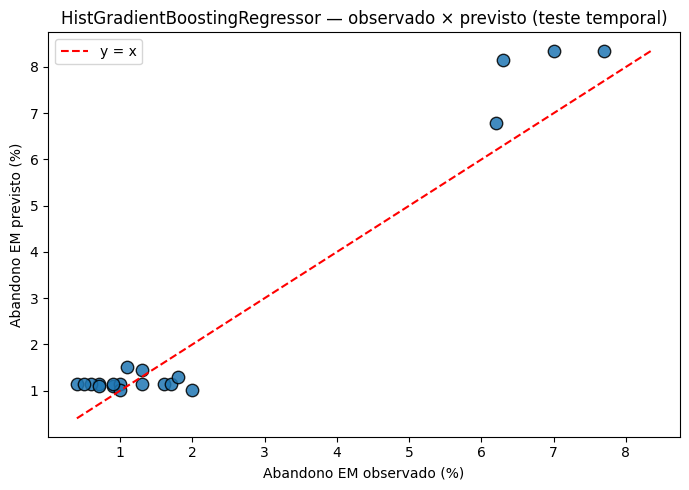

In [6]:
y_test = resultado["y_test"]
y_hat = resultado["y_pred_hgb"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_hat, s=80, alpha=0.85, edgecolors="k")
lim = min(y_test.min(), y_hat.min()), max(y_test.max(), y_hat.max())
ax.plot(lim, lim, "r--", lw=1.5, label="y = x")
ax.set_xlabel("Abandono EM observado (%)")
ax.set_ylabel("Abandono EM previsto (%)")
ax.set_title("HistGradientBoostingRegressor — observado × previsto (teste temporal)")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Leitura dos resultados (modelo principal)

- **MAE** — erro médio em pontos percentuais (menor é melhor).
- **RMSE** — penaliza mais erros grandes.
- **R²** — variância explicada no teste (cuidado com poucas linhas no teste).
- Na **§7** comparam-se **HistGradientBoostingRegressor**, **DecisionTreeRegressor** e **KNeighborsRegressor**; o **KMeans** não entra nestas métricas (não é regressão).


## 7. Comparação dos regressores + KMeans + exportação

### 7.1 Três regressores (mesmo teste temporal)

| Modelo | Métricas no teste |
|--------|-------------------|
| HistGradientBoostingRegressor | MAE, RMSE, R² |
| DecisionTreeRegressor | MAE, RMSE, R² |
| KNeighborsRegressor | MAE, RMSE, R² |

### 7.2 KMeans (complementar)

Segmentação de escolas–ano por perfil de indicadores (cotovelo, silhueta, perfis médios por cluster).

### 7.3 Ajuste do modelo final

O **HistGradientBoostingRegressor** é ajustado com **RandomizedSearchCV** sobre o conjunto de treino, usando **TimeSeriesSplit por ano** para respeitar a ordem temporal.

### 7.4 Validação cruzada e inferência

A suite exporta:

- métricas do modelo final no **teste holdout**;
- média e desvio na **validação cruzada temporal**;
- **curva de aprendizado**;
- **bundle do modelo final** (`outputs/ml/final_model_bundle.pkl`) e função de inferência `edu.predict_taxa_abandono_em(...)`.

### 7.5 Artefatos

`outputs/figures/` (PNG) e `outputs/ml/` (CSV + JSON / PKL) — consumidos pelo dashboard (página 5).


Anos de treino: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017] | teste: [2018, 2019, 2021, 2022]
n_train = 54 | n_test = 20

### Métricas no conjunto de teste temporal


,modelo,mae,rmse,r2
0,DecisionTreeRegressor,0.533333,0.673911,0.916795
1,HistGradientBoosting,0.551607,0.698772,0.910543
2,KNeighborsRegressor,0.854601,1.474601,0.601624


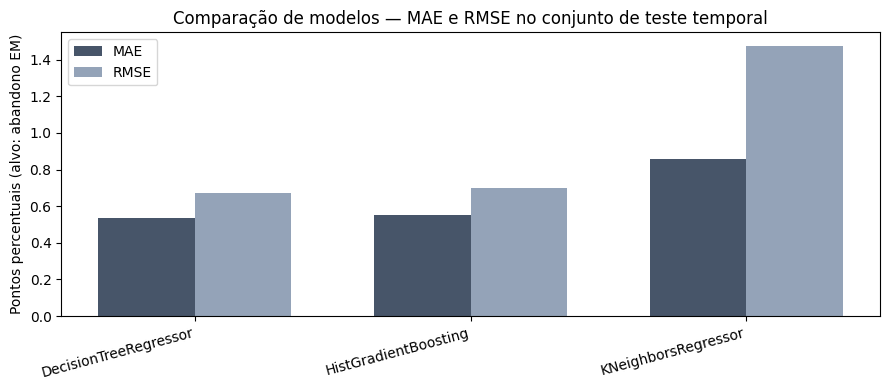

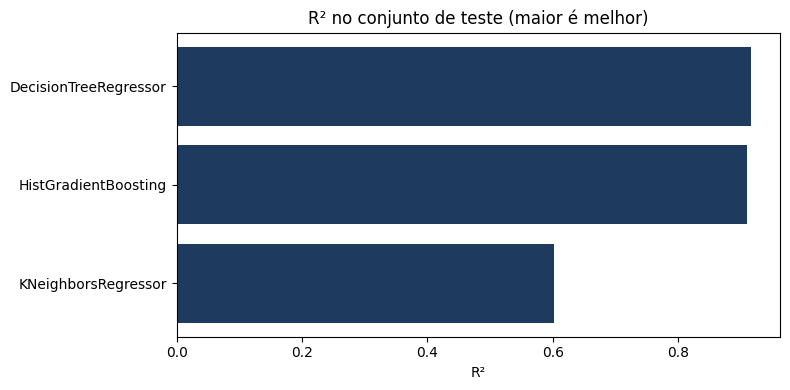

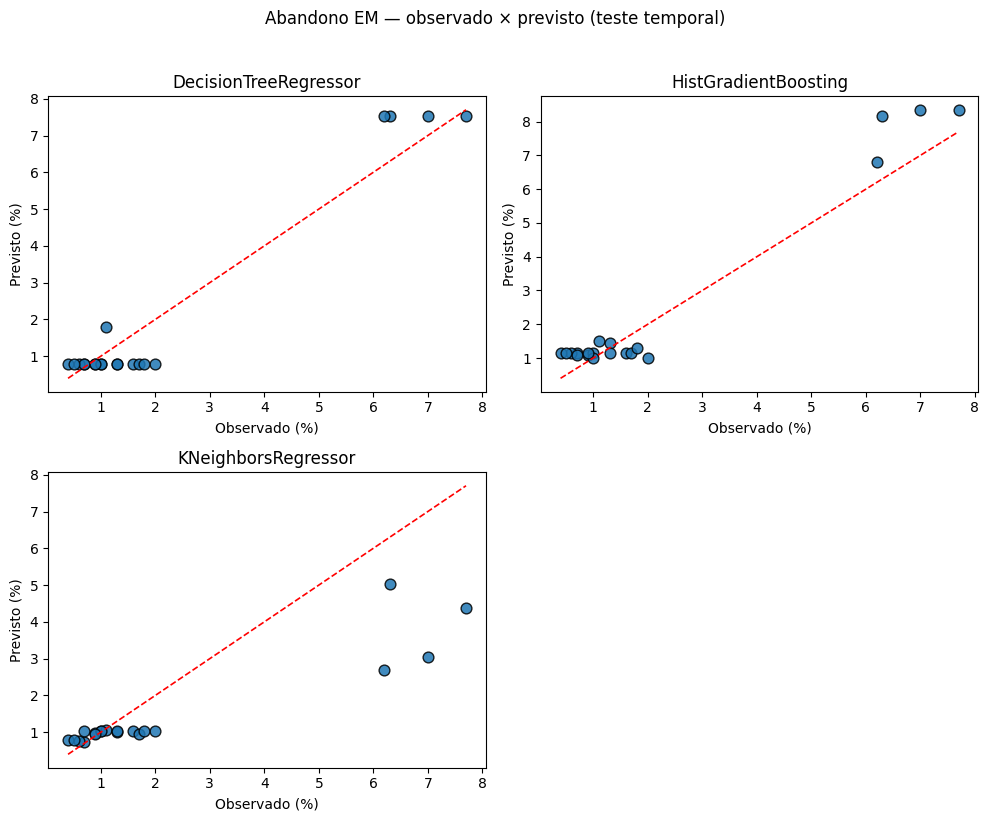

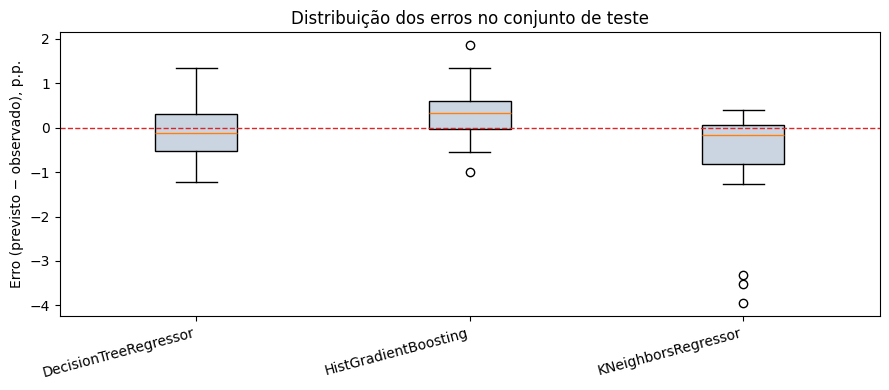

Figuras de comparação gravadas: 4


In [7]:
from IPython.display import display, Markdown

# --- 7.1 Comparação dos três regressores (sem Ridge / ElasticNet / Dummy) ---
cmp = bl.run_model_comparison_experiment(year_cutoff=2017)

print("Anos de treino:", cmp["train_years"], "| teste:", cmp["test_years"])
print("n_train =", cmp["n_train"], "| n_test =", cmp["n_test"])
print()
print("### Métricas no conjunto de teste temporal")
display(bl.metrics_comparison_dataframe(cmp["metrics_by_model"]))

FIG_DIR = ROOT / "outputs" / "figures"
paths_cmp = bl.plot_model_comparison_figures(
    cmp["y_test"],
    cmp["metrics_by_model"],
    cmp["predictions_by_model"],
    save_dir=FIG_DIR,
    show=True,
)
print("Figuras de comparação gravadas:", len(paths_cmp))


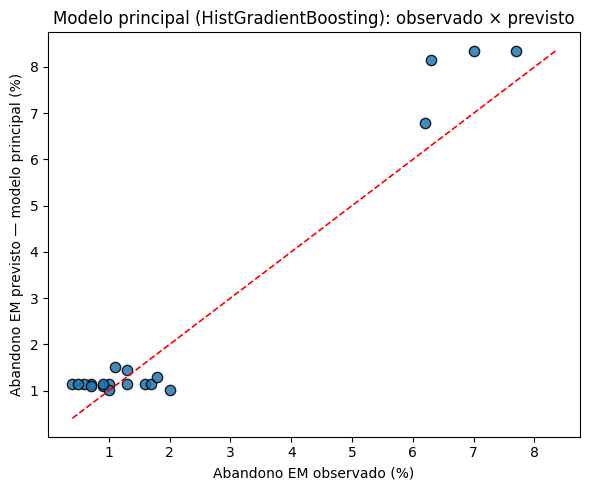

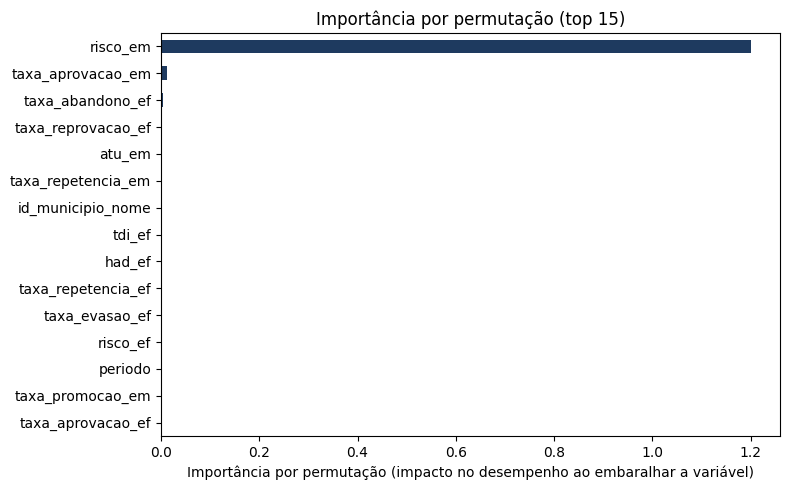

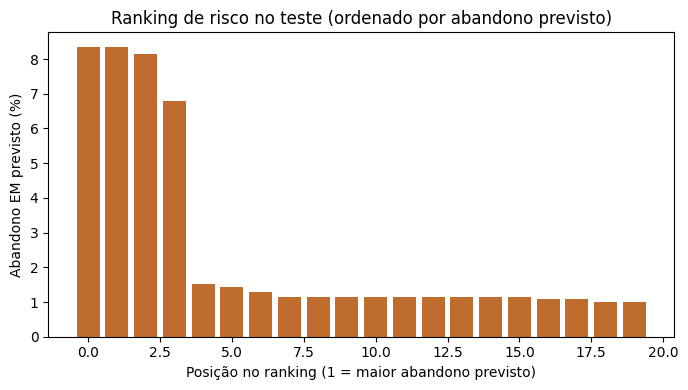

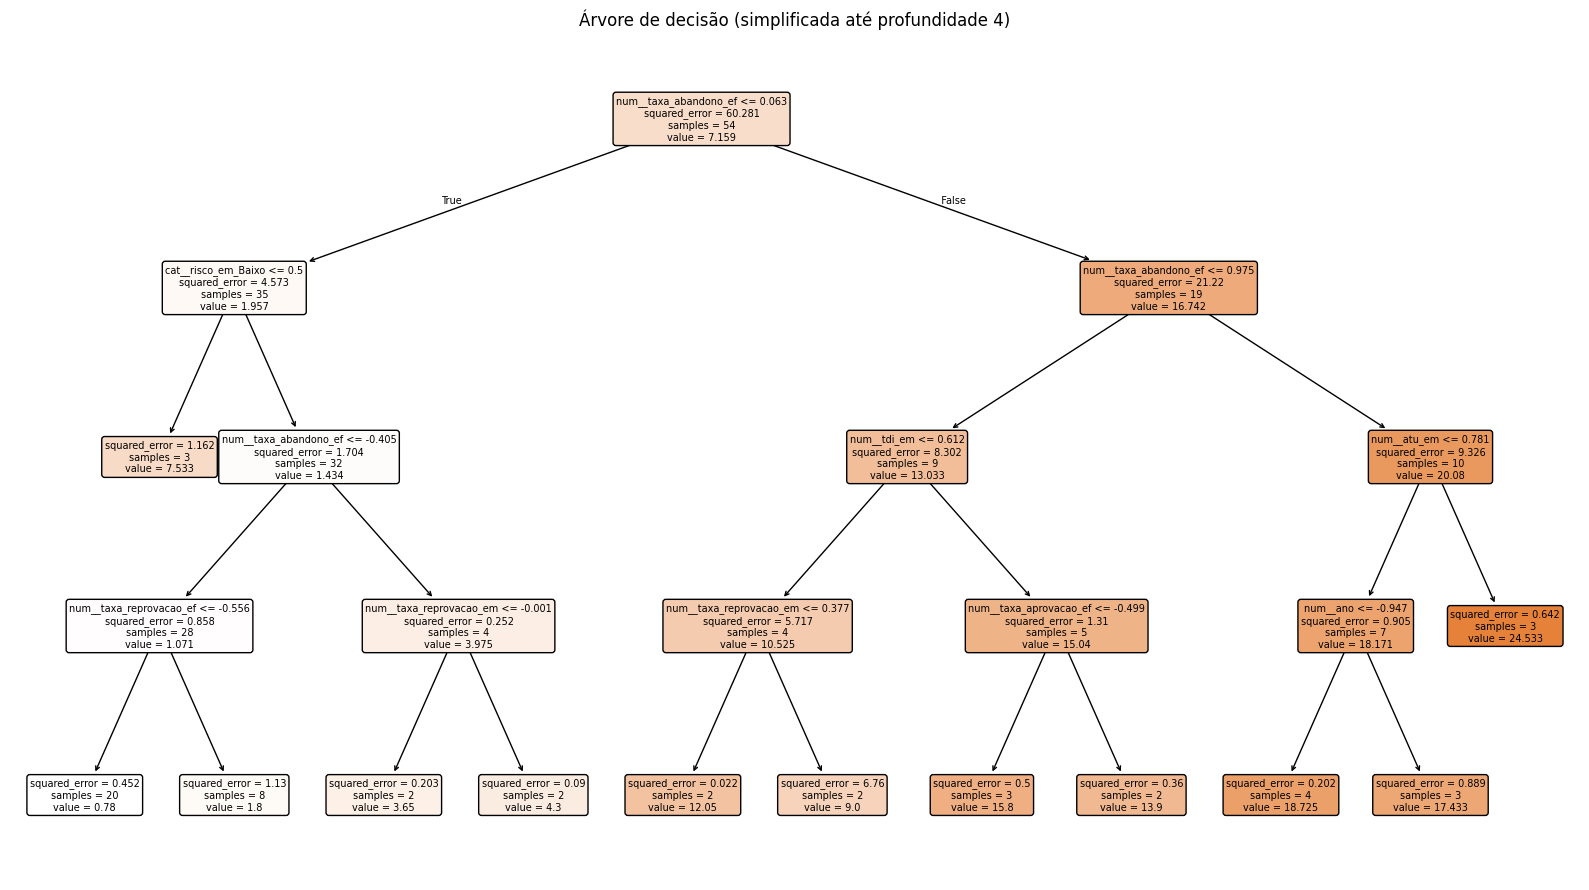

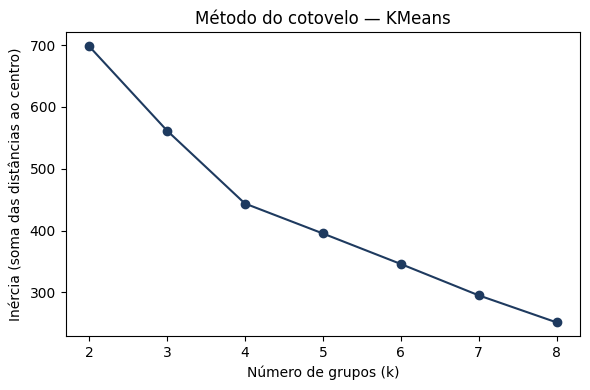

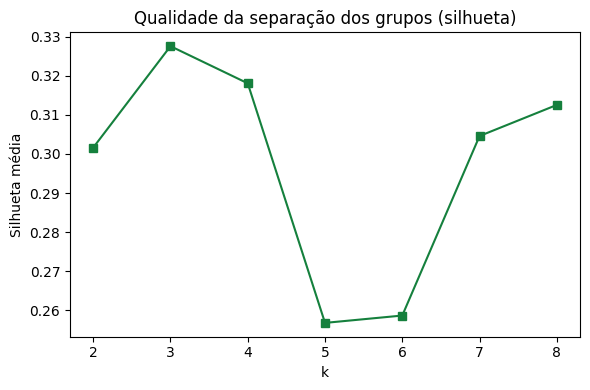

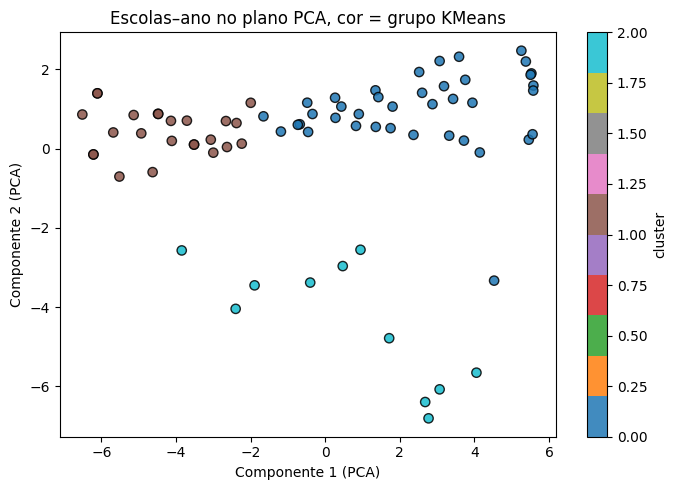

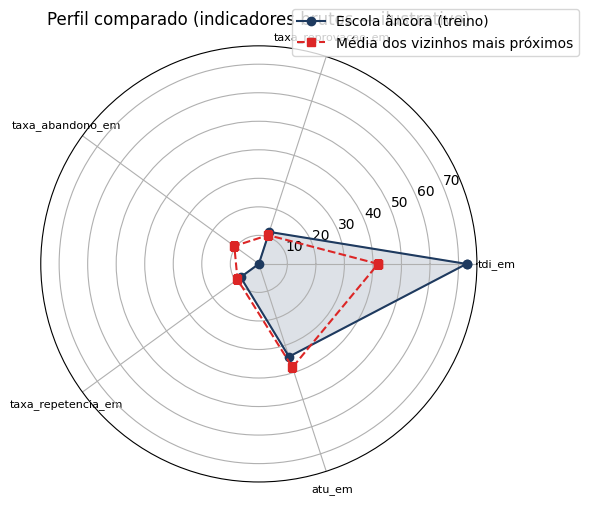

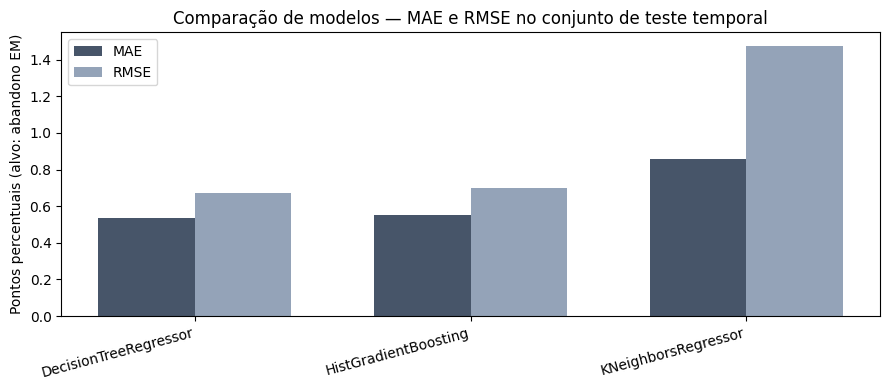

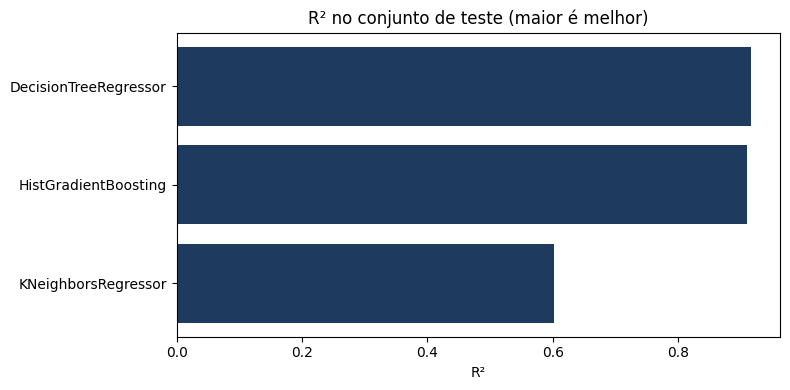

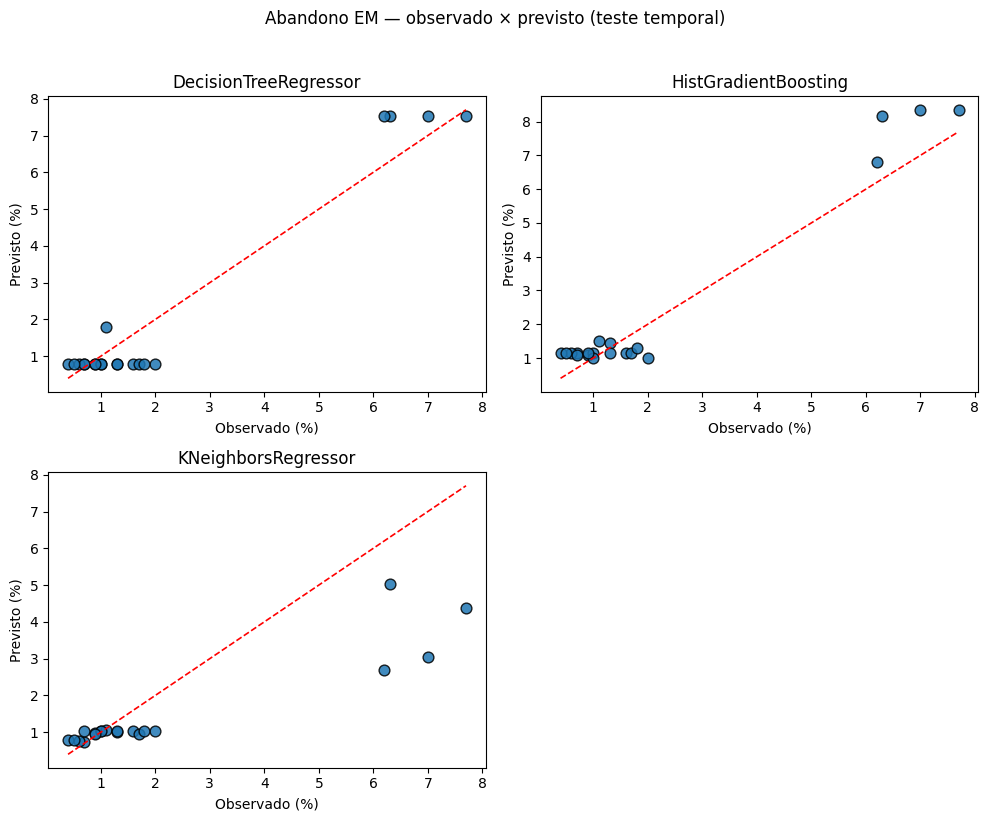

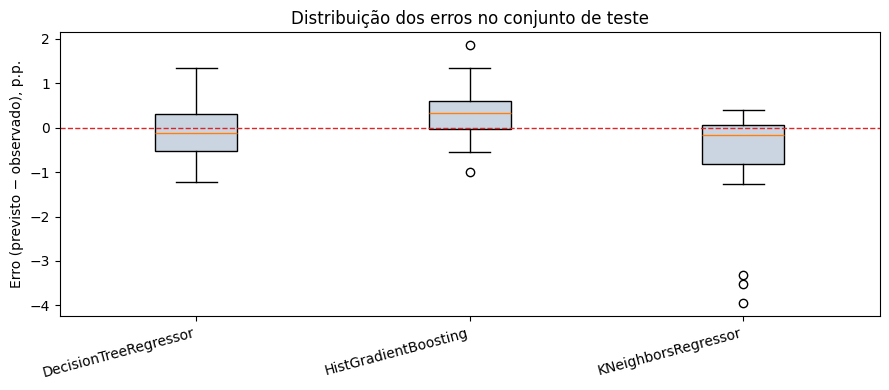

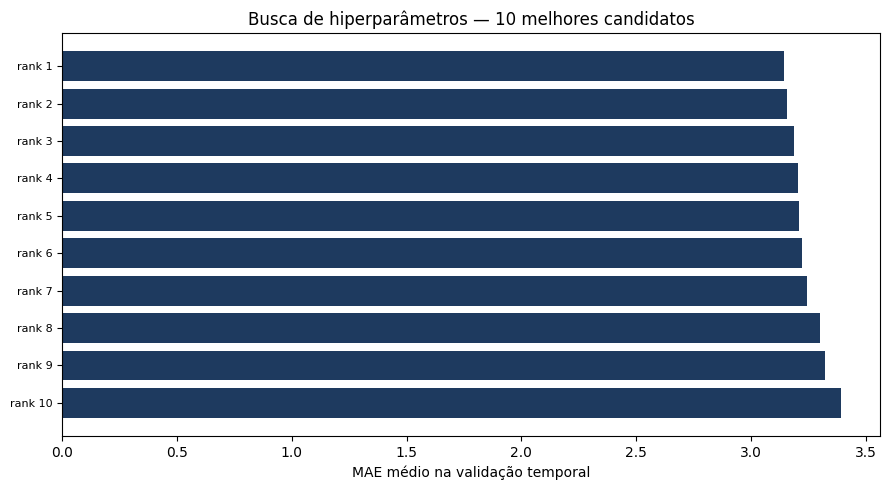

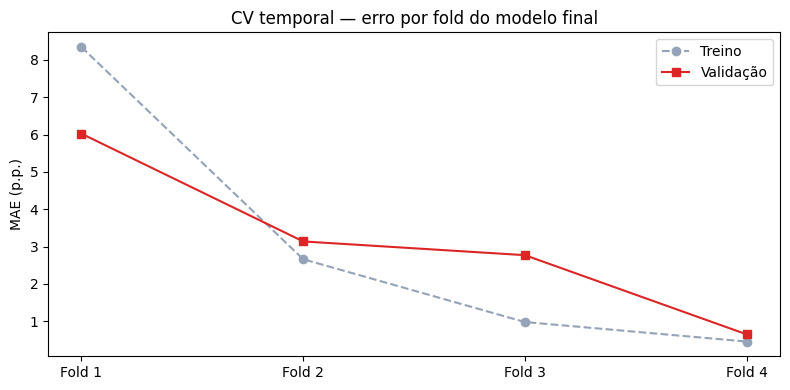

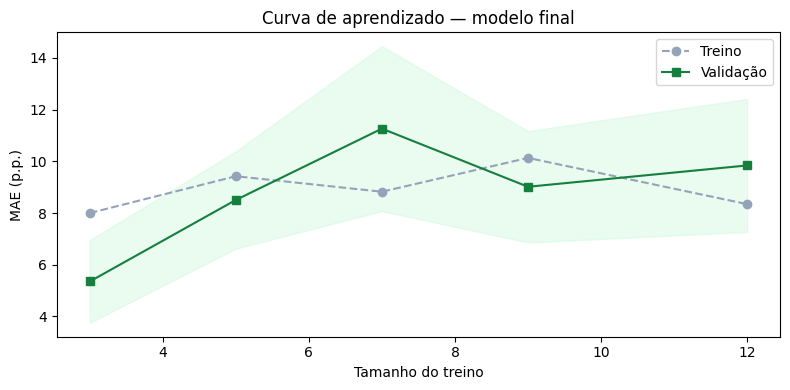

### KMeans
Número de clusters (k): 3


,cluster,taxa_abandono_em,tdi_em,taxa_reprovacao_em,taxa_repetencia_em,atu_em
0,0,1.78,22.78,7.12,6.15,34.30
1,1,13.66,47.66,12.60,10.60,36.85
2,2,3.10,35.75,26.75,7.78,25.71



### Narrativa comparativa (regressores)


Comparamos três modelos de regressão no mesmo período de teste (anos mais recentes). Todos estimam a taxa de abandono no Ensino Médio (%) por escola e ano.

O menor erro médio absoluto (MAE) ficou com **DecisionTreeRegressor** (~0.53 pontos percentuais). Quanto menor o MAE, mais perto as previsões ficam dos valores observados.

**HistGradientBoosting** costuma captar relações não lineares (combinações de indicadores) e tende a ter melhor desempenho preditivo quando há padrão nos dados.

**Árvore de decisão** privilegia clareza: gera regras do tipo “se indicador X passa de um limite, o abandono tende a subir”. O erro costuma ser um pouco maior, mas a leitura para gestores é mais direta.

**K vizinhos (KNN)** prevê olhando para escolas “parecidas” no passado recente — útil para comparar comunidades escolares semelhantes, não só para o número de MAE.

Em números: a árvore teve MAE ~0.53 p.p.; use-a para explicar fatores de risco e o boosting para priorização numérica.


### Perfil dos clusters (texto)


**Grupo 1** — indicadores mais altos: atu_em (34.3), tdi_em (22.8), taxa_reprovacao_em (7.1); entre os mais baixos: taxa_abandono_em (1.8), taxa_repetencia_em (6.2).

**Grupo 2** — indicadores mais altos: tdi_em (47.7), atu_em (36.9), taxa_abandono_em (13.7); entre os mais baixos: taxa_repetencia_em (10.6), taxa_reprovacao_em (12.6).

**Grupo 3** — indicadores mais altos: tdi_em (35.8), taxa_reprovacao_em (26.8), atu_em (25.7); entre os mais baixos: taxa_abandono_em (3.1), taxa_repetencia_em (7.8). O grupo com **maior abandono médio** histórico neste recorte é o grupo 2; o menor abandono médio aparece no grupo 1.


### Modelo final ajustado
HistGradientBoostingRegressor (ajustado)
Métricas no teste: {'mae': 0.7397001723757762, 'rmse': 0.9891476352442707, 'r2': 0.8207468395584075}
Bundle salvo em: /home/fatima/Henrique_projetos/projeto_evasao_escolar/outputs/ml/final_model_bundle.pkl

Artefactos: /home/fatima/Henrique_projetos/projeto_evasao_escolar/outputs/ml
Total de figuras geradas: 15


In [8]:
# --- 7.2 Suite completa: KMeans, tuning, validação temporal e exportação dashboard ---
suite = edu.run_educational_ml_suite(
    year_cutoff=2017,
    save_artifacts=True,
    show_plots=True,
    permutation_repeats=8,
    tuning_iter=18,
    cv_splits=4,
)

print("### KMeans")
print("Número de clusters (k):", suite["kmeans"]["n_clusters"])
display(suite["kmeans"]["profiles"])

print()
print("### Narrativa comparativa (regressores)")
display(Markdown(suite["narrative_comparison"]))

print()
print("### Perfil dos clusters (texto)")
display(Markdown(suite["kmeans"]["profile_text"]))

print()
print("### Modelo final ajustado")
print(suite["final_model_name"])
print("Métricas no teste:", suite["final_model_test_metrics"])
print("Bundle salvo em:", suite["final_model_bundle_path"])

print()
print("Artefactos:", suite["artifact_dir"])
print("Total de figuras geradas:", len(suite["figure_paths"]))


## 8. Ajuste de hiperparâmetros do modelo final

O modelo final é o **HistGradientBoostingRegressor** ajustado por **RandomizedSearchCV** no conjunto de treino, com **TimeSeriesSplit por ano**. A tabela abaixo mostra os candidatos com menor **MAE médio de validação**.

In [9]:
display(suite["tuning_results_table"].head(10))
print("Melhores hiperparâmetros:")
print(suite["final_model_best_params"])
print()
print("Métricas do modelo final no teste holdout:")
print(suite["final_model_test_metrics"])

,rank_test_score,mae_validacao_media,mae_validacao_dp,mae_treino_media,params
0,1,3.145060,1.915187,3.109935,"{'model__min_samples_leaf': 12, 'model__max_le..."
1,2,3.155454,1.909627,3.126762,"{'model__min_samples_leaf': 12, 'model__max_le..."
2,3,3.188084,1.912439,3.143913,"{'model__min_samples_leaf': 12, 'model__max_le..."
3,4,3.206673,1.959420,2.214212,"{'model__min_samples_leaf': 8, 'model__max_lea..."
4,5,3.209545,1.961495,2.229764,"{'model__min_samples_leaf': 8, 'model__max_lea..."
5,6,3.223093,1.928664,2.274632,"{'model__min_samples_leaf': 8, 'model__max_lea..."
6,7,3.245494,1.705816,0.472157,"{'model__min_samples_leaf': 5, 'model__max_lea..."
7,8,3.299027,1.890328,0.175746,"{'model__min_samples_leaf': 5, 'model__max_lea..."
8,9,3.320858,1.821897,2.411660,"{'model__min_samples_leaf': 8, 'model__max_lea..."
9,10,3.392644,1.825391,2.691971,"{'model__min_samples_leaf': 8, 'model__max_lea..."


Melhores hiperparâmetros:
{'model__min_samples_leaf': 12, 'model__max_leaf_nodes': 15, 'model__max_iter': 220, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__l2_regularization': 0.3}

Métricas do modelo final no teste holdout:
{'mae': 0.7397001723757762, 'rmse': 0.9891476352442707, 'r2': 0.8207468395584075}


## 9. Validação cruzada temporal, estabilidade e inferência

A tabela de folds abaixo mostra o comportamento do modelo final ao longo dos cortes temporais do treino. Em seguida, a função `edu.predict_taxa_abandono_em(...)` exemplifica a inferência sobre novas linhas com as mesmas features do pipeline.

In [10]:
display(suite["final_model_cv_folds"])
print("Resumo CV:")
print(suite["final_model_cv_summary"])
print()
display(Markdown(suite["final_model_cv_diagnosis"]))
print()
print("Exemplo de inferência com 3 linhas do próprio dataset:")
base = bl.load_fato_integrado().dropna(subset=[bl.TARGET]).head(3)
pred_demo = edu.predict_taxa_abandono_em(base)
display(pred_demo[["ano", "id_linha_educacional", "pred_taxa_abandono_em"]])

,fold,mae_treino,mae_validacao,rmse_treino,rmse_validacao,r2_treino,r2_validacao
0,1,8.344444,6.025000,9.362321,8.104920,0.000000,-0.233283
1,2,2.661233,3.137815,3.322288,3.581520,0.849961,0.334757
2,3,0.978356,2.769722,1.196524,3.471428,0.979043,-5.990032
3,4,0.455705,0.647705,0.581673,0.969733,0.994803,0.782238


Resumo CV:
{'mae_validacao_media': 3.145060366673588, 'mae_validacao_dp': 1.9151872636058846, 'rmse_validacao_media': 4.031900324602142, 'rmse_validacao_dp': 2.573097543326918, 'r2_validacao_media': -1.2765799760922276, 'r2_validacao_dp': 2.74500600898047, 'mae_treino_media': 3.1099346592740162, 'r2_treino_media': 0.7059519198480793, 'n_folds': 4}



Há **instabilidade temporal relevante**: os folds variam bastante e o erro em validação fica acima do treino. Isso sugere sensibilidade a mudanças de período e possível overfitting.


Exemplo de inferência com 3 linhas do próprio dataset:


,ano,id_linha_educacional,pred_taxa_abandono_em
1,2008,18,0.187206
2,2008,19,1.128054
3,2008,20,18.581063
